## 01. 하이퍼파라미터 튜닝

같은 알고리즘을 사용해도 설정값에 따라 모델 성능이 달라질 수 있다.
예를 들어 KNN의 `n_neighbors`, RandomForest의 `max_depth`, LogisticRegression의 `C`는 사람이 학습 전에 정하는 값이다.

**배우는 이유**
- 모델의 성능과 복잡도를 조절하기 위함.
- 후보 설정을 감으로 고르지 않고 검증 점수로 비교하기 위함.
- 테스트 데이터를 반복 사용하지 않고 모델을 개선하기 위함.

**핵심 용어**
- parameter: 모델이 데이터에서 학습하는 값. 예: 회귀계수, 트리 분기 기준.
- hyperparameter: 사람이 학습 전에 정하는 설정값. 예: `max_depth`, `C`, `n_estimators`.
- Grid Search: 후보 조합을 모두 확인하는 방법.
- Random Search: 후보 중 일부를 무작위로 확인하는 방법.
- `best_estimator_`: 가장 좋은 후보로 다시 학습된 최종 모델.

## 02. 실습 환경 준비

Wine 다중분류 데이터를 사용해 LogisticRegression과 RandomForest의 하이퍼파라미터를 비교한다.
스케일링이 필요한 모델은 Pipeline으로 전처리와 모델을 묶어 튜닝한다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from altair.datasets import data

from sklearn.datasets import load_wine

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report

## 03. Wine 데이터 로드

Wine 데이터는 와인의 화학 성분으로 3개 품종을 예측하는 다중분류 데이터셋이다.
수치 feature의 단위와 범위가 다르므로 LogisticRegression에는 스케일링을 함께 적용한다.


In [2]:
wine = load_wine(as_frame=True)

wine_X = wine.data
wine_y = wine.target

print('feature shape:', wine_X.shape)
print('target shape:', wine_y.shape)
print('target names:', wine.target_names)
display(wine_X.head())
display(wine_y.value_counts().sort_index())


feature shape: (178, 13)
target shape: (178,)
target names: ['class_0' 'class_1' 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


target
0    59
1    71
2    48
Name: count, dtype: int64

## 04. 학습/평가 데이터 분리

튜닝은 학습 데이터 내부 교차검증으로 수행하고, test 데이터는 마지막 확인용으로 남겨둔다.


In [3]:
wine_X_train, wine_X_test, wine_y_train, wine_y_test = train_test_split(
    wine_X,
    wine_y,
    test_size=0.2,
    random_state=42,
    stratify=wine_y
)

print('train:', wine_X_train.shape, wine_y_train.shape)
print('test:', wine_X_test.shape, wine_y_test.shape)


train: (142, 13) (142,)
test: (36, 13) (36,)


## 05. 기본 Pipeline 모델 평가

튜닝 전 기본 모델을 먼저 학습해 기준 성능을 확인한다.
이 기준이 있어야 튜닝 후 성능이 실제로 개선되었는지 비교할 수 있다.



In [5]:
baseline_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=3000))
])

# 학습
baseline_pipeline.fit(wine_X_train, wine_y_train)

# 예측
baseline_pred = baseline_pipeline.predict(wine_X_test)

# print(baseline_pred)

# accuracy: 분류 정확도(정답률)
print('baseline accuracy: ', accuracy_score(wine_y_test, baseline_pred))

print('baseline f1_macro', f1_score(wine_y_test, baseline_pred, average='macro'))

[0 1 0 1 1 0 0 1 1 2 1 2 0 2 0 1 1 0 1 0 1 1 0 0 1 1 0 2 1 2 0 2 1 2 2 2]


### accuracy
- 실제 값과 예측값의 정확도(정답률)

### precision
- 실제 정답 개수 / 예측한 정답 개수
- 모델이 예측한 값과 정답의 비율을 나타내는 값
- precision이 높음 == 모델이 예측을 잘함
- ex) 고객 이탈 예측
    - 모델이 20명 이탈할 것으로 예측
    - 12 / 20 == 0.6 == precision

### recall
- 특정 class에 대한 모델이 예측한 정답 개수 / 실제 정답 개수
- recall 값이 높음 == 모델이 예측을 잘함
- ex) 고객 이탈 예측
    - 실제로 이탈한 고객이 30명이 있음
    - 모델이 그 중 18명을 찾아냈다(예측했다)
    - 18 / 30 == 0.6 == recall

### f1-score
- precision과 recall의 균형을 보여주는 점수
- precision은 높은데, recall 낮음 -> 예측한 것과 다르게 실제 값이 높음
    - 예측한 이탈 고객보다 실제 이탈한 고객이 더 많음

- precision은 낮은데, recall 높음 -> 예측을 너무 널널하게 해서 정확도가 떨어짐
    - 이탈할 것으로 예측되는 고객의 수를 너무 많이 잡음
        -  == 이탈하지 않을 수 있는 고객도 후보로 많이 포함 시킴


### f1-macro
- f1-score를 class 별로 각각 구한 뒤 평균을 낸 값
    - ex)
        - class0의 f1-score = 0.9
        - class1의 f1-score = 0.7
        - class2의 f1-score = 0.5
        - f1_macro = ( 0.9 + 0.7 + 0.5) / 3 = 0.7

## 06. GridSearchCV로 LogisticRegression 튜닝

GridSearchCV는 지정한 후보 조합을 모두 비교한다.
Pipeline 내부 모델의 하이퍼파라미터는 `model__C`처럼 `단계이름__파라미터명` 형식으로 지정한다.


In [8]:
# LogisticRegression의 C == 규제강도
# - 기울기 == 가중치 == 회귀계수(coefficient)
# - 모델이 학습 시 회귀계수가 커지지 않도록 적용하는 규제의 수치
# - 역수로 작용 == 작을수록 규제가 강하다
# - C 값은 클수록 규제가 약해져 훈련 데이터에 잘 맞추려는 모습을 보임
# == C 값이 너무 커지면 과대적합 가능성이 커진다.'

# class_weight
# - class 별 샘플 수 비중
# - 'balanced' : class 별 샘플 수 차이를 균형있게 보정하는 설정
#   샘플 수가 적은 class의 오답에 더 큰 가중치를 줘서
#   해당 class가 예측 시 무시되지 않도록 학습시킴
logistic_param_grid = {
    'model__C': [0.01, 0.1 ,1, 10],
    'model__class_weight': [None, 'balanced'],
}

# GridSearchCV() : 모든 param_grid의 후보 조합에 맞춰 모델 생성 후 교차 검증

logistic_grid = GridSearchCV(
    estimator= baseline_pipeline, # 사용할 모델 지정
    param_grid= logistic_param_grid, # 모델에 적용할 하이퍼파라미터 후보
    scoring='accuracy', # 좋은 하이퍼파라미터를 차지 위한 평가 기준
    cv=5, # train 데이터를 5개로 fold 하여 교차 검증을 수행
    n_jobs= 1, # 병렬 처리 X
    refit = True # 가장 좋은 하이퍼 파라미터 조합으로 전체 train 데이터를 다시 학습
)

logistic_grid.fit(wine_X_train, wine_y_train)

print('best_params: ', logistic_grid.best_params_)
print('best_score: ', logistic_grid.best_score_)
print('beset_estimator: ', logistic_grid.best_estimator_)

best_params:  {'model__C': 0.1, 'model__class_weight': None}
best_score:  0.993103448275862
beset_estimator:  Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(C=0.1, max_iter=3000))])


## 07. cv_results_ 해석

`cv_results_`에는 각 후보 조합의 평균 점수, 표준편차, 순위, 학습 시간이 들어 있다.
평균 점수뿐 아니라 표준편차도 함께 보면 후보의 안정성을 판단하는 데 도움이 된다.

그래프에서는 `C` 변화와 `class_weight` 설정에 따라 평균 검증 점수가 어떻게 달라지는지 확인한다.


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,param_model__class_weight,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.0073,0.0016,0.0029,0.0011,0.01,NaN,"{'model__C': 0.01, 'model__class_weight': None}",1.0,0.9310,0.9643,1.0000,1.0,0.9791,0.0277,7
1,0.0083,0.0014,0.0023,0.0007,0.01,balanced,"{'model__C': 0.01, 'model__class_weight': 'bal...",1.0,0.9310,0.9643,0.9643,1.0,0.9719,0.0259,8
2,0.0051,0.0007,0.0022,0.0000,0.10,NaN,"{'model__C': 0.1, 'model__class_weight': None}",1.0,0.9655,1.0000,1.0000,1.0,0.9931,0.0138,1
3,0.0059,0.0007,0.0021,0.0001,0.10,balanced,"{'model__C': 0.1, 'model__class_weight': 'bala...",1.0,0.9310,1.0000,1.0000,1.0,0.9862,0.0276,3
4,0.0063,0.0002,0.0021,0.0001,1.00,NaN,"{'model__C': 1, 'model__class_weight': None}",1.0,0.9655,1.0000,1.0000,1.0,0.9931,0.0138,1
5,0.0063,0.0004,0.0021,0.0001,1.00,balanced,"{'model__C': 1, 'model__class_weight': 'balanc...",1.0,0.9655,1.0000,0.9643,1.0,0.9860,0.0172,4
6,0.0141,0.0096,0.0078,0.0096,10.00,NaN,"{'model__C': 10, 'model__class_weight': None}",1.0,0.9655,1.0000,0.9643,1.0,0.9860,0.0172,4
7,0.0087,0.0001,0.0021,0.0001,10.00,balanced,"{'model__C': 10, 'model__class_weight': 'balan...",1.0,0.9655,1.0000,0.9643,1.0,0.9860,0.0172,4


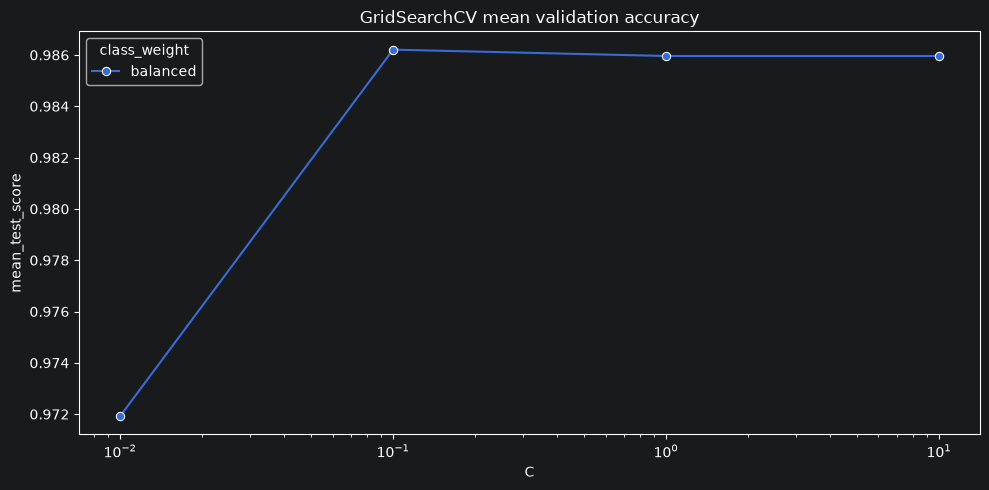

In [14]:
grid_result_df = pd.DataFrame(logistic_grid.cv_results_)

display(grid_result_df.round(4))

plt.figure(figsize=(10, 5))
sns.lineplot(
    data = grid_result_df,
    x = 'param_model__C',
    y = 'mean_test_score',
    hue = 'param_model__class_weight',
    marker = 'o',
)

plt.xscale('log')
plt.title('GridSearchCV mean validation accuracy')
plt.xlabel('C')
plt.ylabel('mean_test_score')
plt.legend(title='class_weight')
plt.tight_layout()
plt.show()

## 08. GridSearchCV 최종 test 평가

튜닝이 끝나면 `best_estimator_`를 test 데이터로 마지막 평가한다.
테스트 점수는 튜닝에 사용하지 않은 데이터에서 최종 일반화 성능을 확인하는 값이다.



In [16]:
best_logistic_model = logistic_grid.best_estimator_

# 최적의 하이퍼 파라미터가 설정된 모델에 test 데이터를 집어넣어 예측
logistic_test_pred = best_logistic_model.predict(wine_X_test)

print("test accuracy: ", accuracy_score( wine_y_test, logistic_test_pred))
print("test f1_macro: ", f1_score( wine_y_test, logistic_test_pred, average='macro'))

test accuracy:  1.0
test f1_macro:  1.0


## 09. RandomizedSearchCV로 RandomForest 튜닝

RandomizedSearchCV는 후보 전체를 모두 보지 않고 일부 조합만 무작위로 확인한다.
후보 조합이 많을 때 탐색 시간을 줄이는 데 유용하다.



In [17]:
# RandomForestClassifier(): 여러 결정트리를 학습하고 투표로 분류하는 앙상블 모델.
rf_clf = RandomForestClassifier(random_state=42)

# param_distributions: 무작위로 뽑을 후보 목록.
# n_estimators는 트리 개수, max_depth는 트리 깊이 제한, min_samples_leaf는 leaf에 필요한 최소 샘플 수.
rf_param_distributions = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 2, 3, 4, 5],
    'min_samples_leaf': [1, 2, 4]
}

# n_iter=8: 전체 조합 중 8개만 무작위로 평가한다.
rf_random_search = RandomizedSearchCV(
    estimator=rf_clf,
    param_distributions=rf_param_distributions,
    n_iter=8,
    cv=5,
    scoring='accuracy',
    random_state=42,
    refit=True
)

rf_random_search.fit(wine_X_train, wine_y_train)

print('best_params:', rf_random_search.best_params_)
print('best_cv_accuracy:', round(rf_random_search.best_score_, 4))
print('test_accuracy:', round(rf_random_search.best_estimator_.score(wine_X_test, wine_y_test), 4))

best_params: {'n_estimators': 50, 'min_samples_leaf': 2, 'max_depth': 5}
best_cv_accuracy: 0.9862
test_accuracy: 1.0


## 10. 튜닝 결과 비교

기본 모델, GridSearchCV 모델, RandomizedSearchCV 모델을 한 표로 비교한다.
수업에서는 단순히 가장 높은 점수만 보지 말고, 모델 복잡도와 해석 가능성도 함께 언급하면 좋다.



In [18]:
comparison_rows = []

comparison_rows.append({
    'model': 'baseline_logistic_pipeline',
    'cv_method': 'none',
    'test_accuracy': accuracy_score(wine_y_test, baseline_pred),
    'test_f1_macro': f1_score(wine_y_test, baseline_pred, average='macro')
})

comparison_rows.append({
    'model': 'grid_logistic_pipeline',
    'cv_method': 'GridSearchCV',
    'test_accuracy': accuracy_score(wine_y_test, logistic_test_pred),
    'test_f1_macro': f1_score(wine_y_test, logistic_test_pred, average='macro')
})

rf_test_pred = rf_random_search.best_estimator_.predict(wine_X_test)
comparison_rows.append({
    'model': 'random_forest',
    'cv_method': 'RandomizedSearchCV',
    'test_accuracy': accuracy_score(wine_y_test, rf_test_pred),
    'test_f1_macro': f1_score(wine_y_test, rf_test_pred, average='macro')
})

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df.round(4))

,model,cv_method,test_accuracy,test_f1_macro
0,baseline_logistic_pipeline,none,0.9722,0.971
1,grid_logistic_pipeline,GridSearchCV,1.0000,1.000
2,random_forest,RandomizedSearchCV,1.0000,1.000


## 11. 튜닝할 때 주의할 점

- test 데이터로 하이퍼파라미터를 계속 고르면 test 데이터에 과하게 맞는 문제가 생김.
- 후보 범위가 너무 넓으면 시간이 오래 걸리고, 너무 좁으면 좋은 설정을 놓칠 수 있음.
- 평균 점수만 보지 말고 fold별 흔들림도 확인해야 함.
- 스케일링이 필요한 모델은 Pipeline으로 묶어 튜닝해야 데이터 누수를 줄일 수 있음.
- 튜닝이 끝난 최종 모델은 다음 단원에서 joblib으로 저장해 재사용할 수 있음.